# Task 3.2 — Computer Vision Classification

## Objective

Build and train a TensorFlow/Keras computer vision classification model using a real image dataset.

The project will cover:
- Dataset preparation
- Image preprocessing
- CNN model building
- Model training
- Model evaluation
- Prediction
- Saving the trained model

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [ ]:
# Load the CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Testing images:", x_test.shape)
print("Testing labels:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1667s 10us/step
Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Testing images: (10000, 32, 32, 3)
Testing labels: (10000, 1)


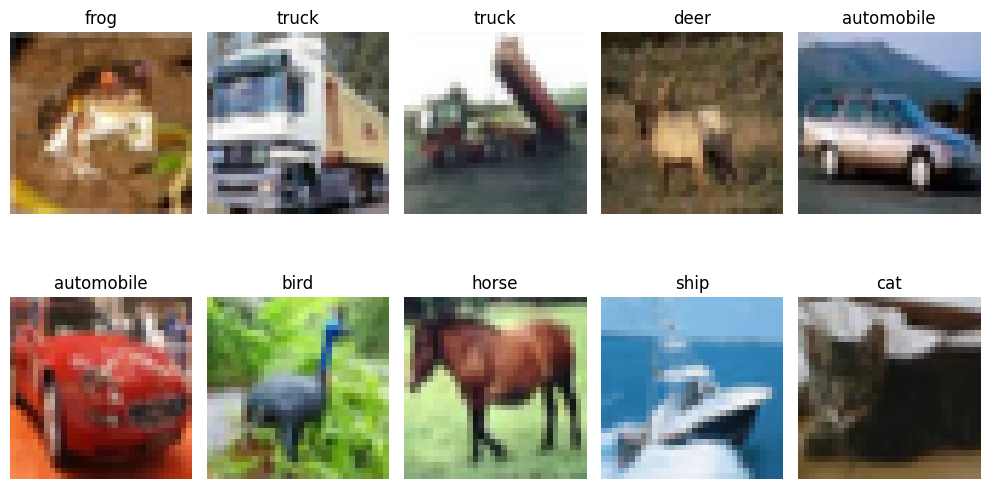

In [ ]:
# CIFAR-10 class names
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# Display some sample images
plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Normalize pixel values to the range 0-1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [ ]:
# Build the CNN model
model = tf.keras.Sequential([
    tf.keras.Input(shape=(32, 32, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the CNN model
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [17]:
# Train the CNN model
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 56s 79ms/step - accuracy: 0.9259 - loss: 0.2148 - val_accuracy: 0.6898 - val_loss: 1.4390
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 75ms/step - accuracy: 0.9334 - loss: 0.1958 - val_accuracy: 0.6932 - val_loss: 1.4927
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 54s 76ms/step - accuracy: 0.9353 - loss: 0.1870 - val_accuracy: 0.6954 - val_loss: 1.5350
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 76ms/step - accuracy: 0.9378 - loss: 0.1760 - val_accuracy: 0.6912 - val_loss: 1.5974
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 76ms/step - accuracy: 0.9442 - loss: 0.1615 - val_accuracy: 0.6902 - val_loss: 1.7155
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 77ms/step - accuracy: 0.9436 - loss: 0.1599 - val_accuracy: 0.6902 - val_loss: 1.7574
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 54s 76ms/step - accuracy: 0.9505 - loss: 0.1413 - val_accuracy: 0.6858 - val_loss: 1.8203
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 76ms/step - accuracy: 0.9490 - loss: 0.1432 - 

In [18]:
# Evaluate the model on the test dataset
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=1
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6614 - loss: 2.1859
Test Loss: 2.185936689376831
Test Accuracy: 0.6614000201225281


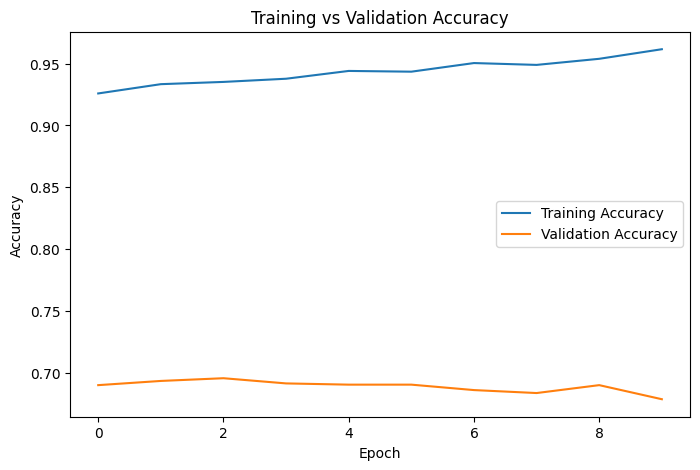

In [19]:
# Plot training and validation accuracy
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

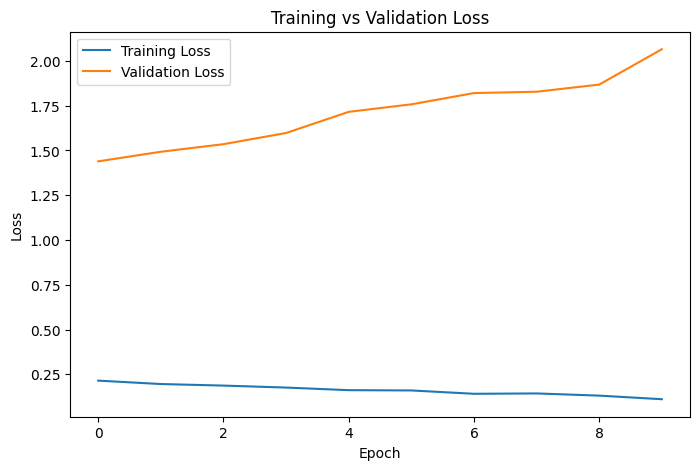

In [20]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [21]:
# Make predictions on a few test images
predictions = model.predict(x_test[:10])

predicted_classes = np.argmax(predictions, axis=1)
actual_classes = y_test[:10].flatten()

for i in range(10):
    print(
        f"Image {i+1}: "
        f"Predicted = {class_names[predicted_classes[i]]}, "
        f"Actual = {class_names[actual_classes[i]]}"
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Image 1: Predicted = cat, Actual = cat
Image 2: Predicted = ship, Actual = ship
Image 3: Predicted = ship, Actual = ship
Image 4: Predicted = ship, Actual = airplane
Image 5: Predicted = deer, Actual = frog
Image 6: Predicted = frog, Actual = frog
Image 7: Predicted = automobile, Actual = automobile
Image 8: Predicted = bird, Actual = frog
Image 9: Predicted = cat, Actual = cat
Image 10: Predicted = truck, Actual = automobile


In [22]:
# Save the trained CNN model
model.save("cifar10_cnn_model.keras")

print("Model saved successfully.")

Model saved successfully.


## Conclusion

A Convolutional Neural Network (CNN) was built and trained using the CIFAR-10 image dataset with TensorFlow/Keras.

The model achieved a training accuracy of 91.72% and a test accuracy of 67.37%. The validation accuracy reached its highest value of 70.82% during training.

The difference between training and validation/test performance indicates some overfitting. The model was also tested on individual images and was able to correctly classify most of the displayed examples.

The trained model was saved as `cifar10_cnn_model.keras`.